In [14]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt
import spikeinterface.extractors as se
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np
from spikeinterface.extractors import SpikeGadgetsRecordingExtractor

In [15]:
# Parameters
elec_noise_freq = 60
min_freq = 30
max_freq = 200
resample_rate = 1000
datapath = r"E:\heart_rate_recording\20250205_101517_ECG_freely_moving.rec\20250205_101517_ECG_freely_moving.rec"
# Load and preprocess the recording
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)
traces = recording.get_traces()

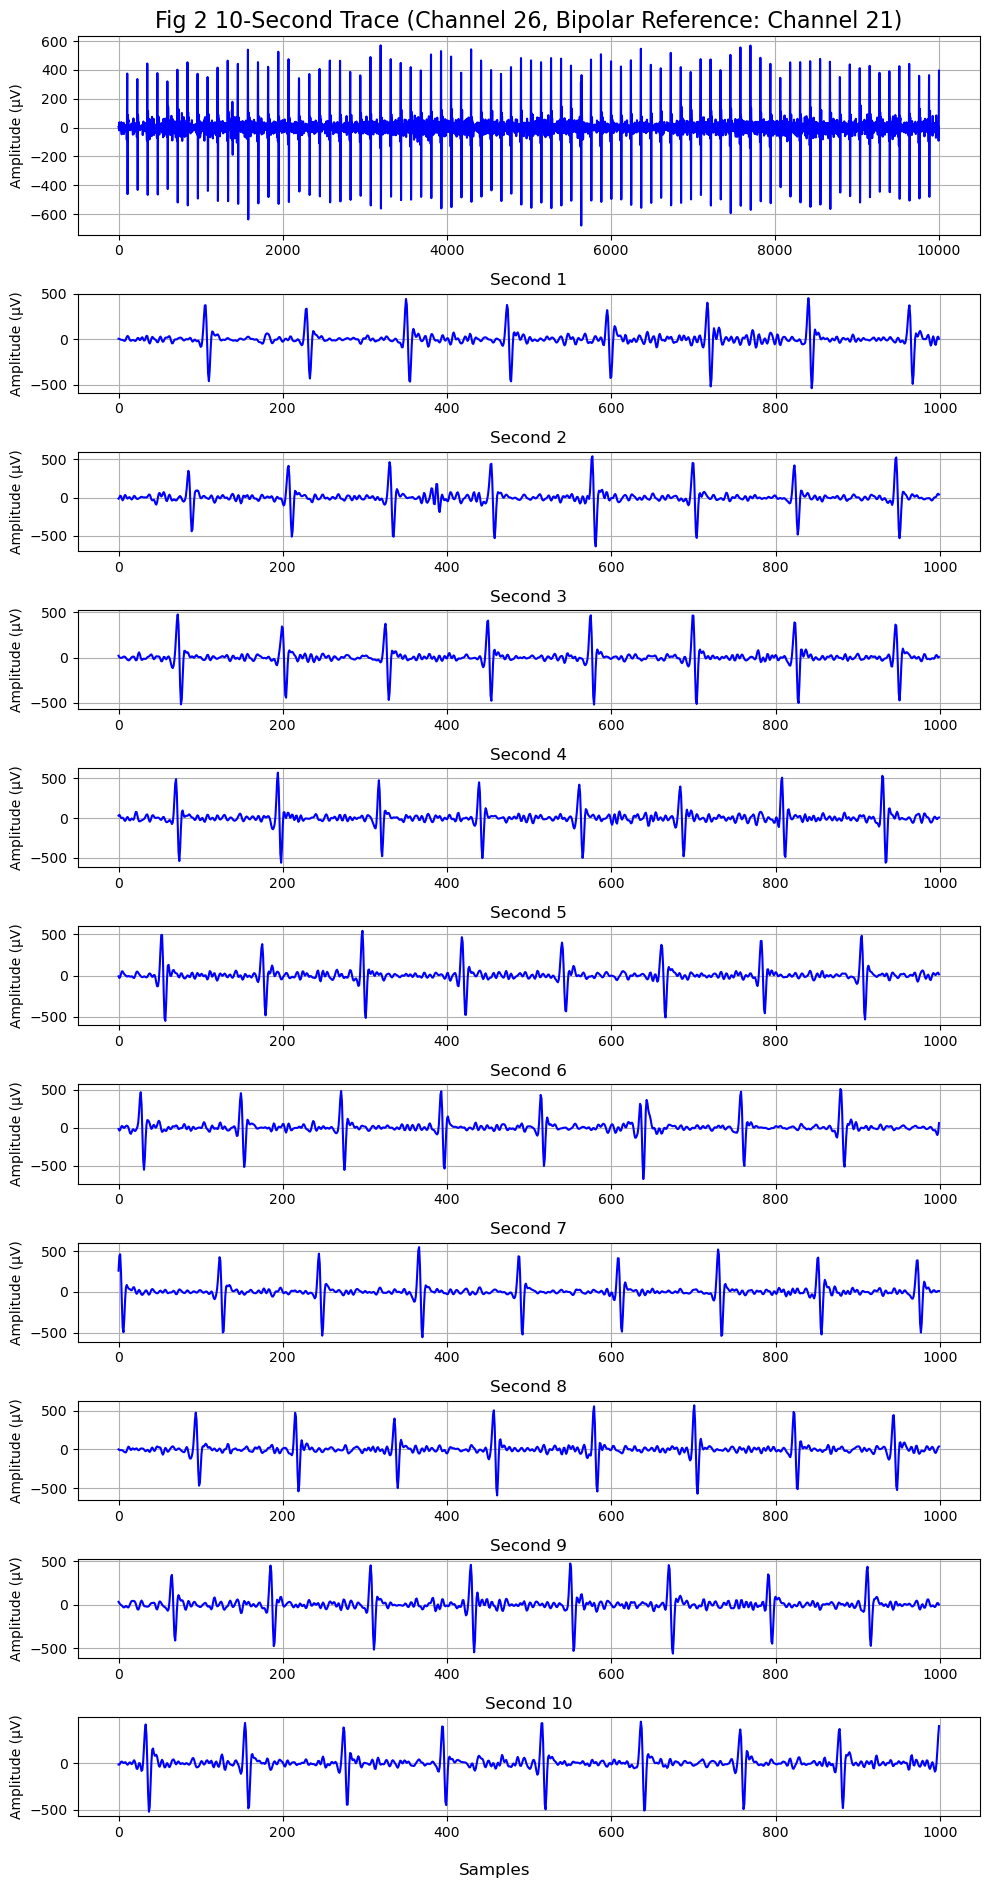

In [16]:
# Subtract Bipolar Reference
ref_channel = 21  # Define the reference channel
traces_bipolar = traces - traces[:, ref_channel, np.newaxis]  # Subtract reference channel from all others

# Define chunking parameters
samples_per_second = resample_rate
samples_per_10sec = 10 * samples_per_second
samples_per_1sec = samples_per_second

# Select the start of the chunk (e.g., first 10 seconds of recording)
start_idx = 0
end_idx = start_idx + samples_per_10sec

# Extract the 10-second trace for a specific channel (e.g., channel 26)
channel = 26
ten_sec_trace = traces_bipolar[start_idx:end_idx, channel]

# Convert data to microvolts if necessary
scaling_factor = 0.195  # Example: conversion from ADC units to µV
ten_sec_trace = ten_sec_trace * scaling_factor

# Create a figure with one large plot for the 10-second trace and subplots for 1-second chunks
fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(11, 1, height_ratios=[2] + [1] * 10)  # 1 large plot + 10 smaller plots

# Plot the full 10-second trace at the top
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ten_sec_trace, color='b')
ax1.set_title(f"Fig 2 10-Second Trace (Channel {channel}, Bipolar Reference: Channel {ref_channel})", fontsize=16)
ax1.set_ylabel("Amplitude (µV)")
ax1.grid()

# Plot the 1-second subplots
for i in range(10):
    chunk_start = i * samples_per_1sec
    chunk_end = chunk_start + samples_per_1sec
    ax = fig.add_subplot(gs[i + 1, 0])
    ax.plot(ten_sec_trace[chunk_start:chunk_end], color='b')
    ax.set_title(f"Second {i + 1}")
    ax.set_ylabel("Amplitude (µV)")
    ax.grid()

# Add a common x-axis label
fig.text(0.5, 0.04, "Samples", ha='center', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

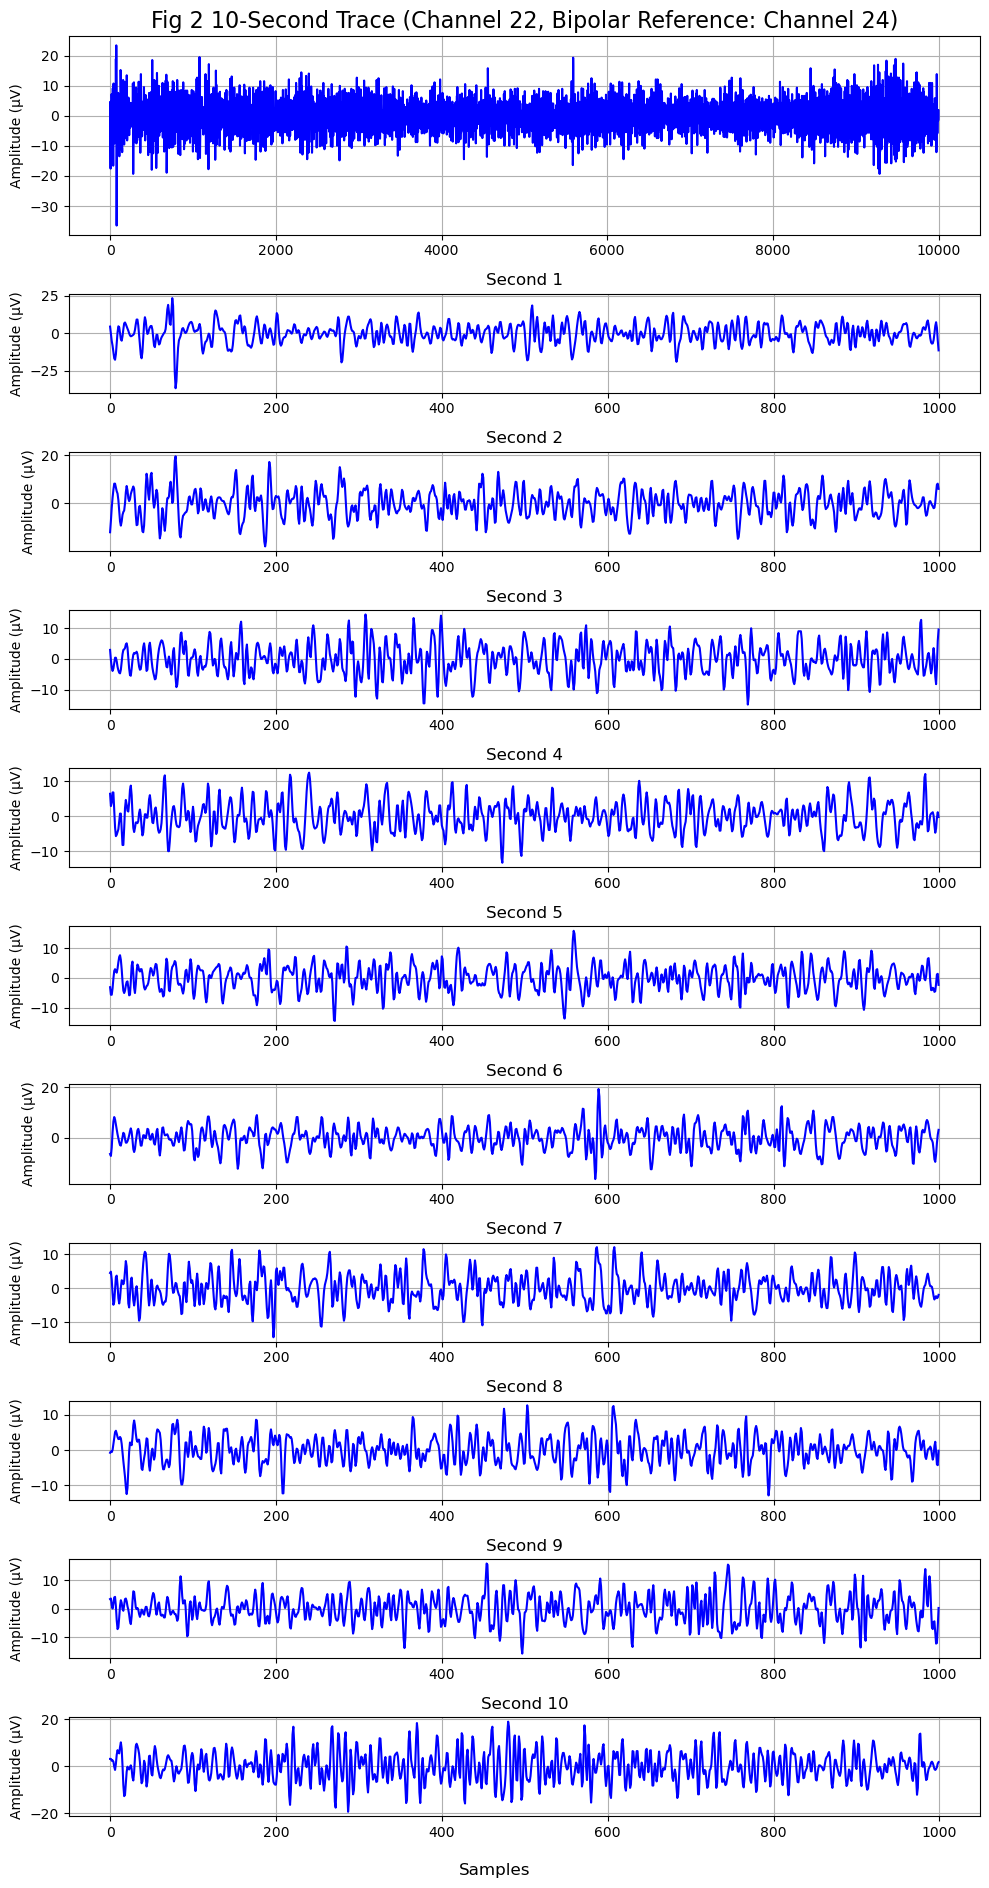

In [17]:
# Parameters
elec_noise_freq = 60
min_freq = 30
max_freq = 200
resample_rate = 1000
datapath = r"E:\Aim1\AIM1\Day1_new\RI1_s3_5_p5_4_nRB3_20250621_105014.rec\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.rec"
# Load and preprocess the recording
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)
traces = recording.get_traces()
# Subtract Bipolar Reference
ref_channel = 24  # Define the reference channel
traces_bipolar = traces - traces[:, ref_channel, np.newaxis]  # Subtract reference channel from all others

# Define chunking parameters
samples_per_second = resample_rate
samples_per_10sec = 10 * samples_per_second
samples_per_1sec = samples_per_second

# Select the start of the chunk (e.g., first 10 seconds of recording)
start_idx = 0
end_idx = start_idx + samples_per_10sec

# Extract the 10-second trace for a specific channel (e.g., channel 26)
channel = 22
ten_sec_trace = traces_bipolar[start_idx:end_idx, channel]

# Convert data to microvolts if necessary
scaling_factor = 0.195  # Example: conversion from ADC units to µV
ten_sec_trace = ten_sec_trace * scaling_factor

# Create a figure with one large plot for the 10-second trace and subplots for 1-second chunks
fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(11, 1, height_ratios=[2] + [1] * 10)  # 1 large plot + 10 smaller plots

# Plot the full 10-second trace at the top
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ten_sec_trace, color='b')
ax1.set_title(f"Fig 2 10-Second Trace (Channel {channel}, Bipolar Reference: Channel {ref_channel})", fontsize=16)
ax1.set_ylabel("Amplitude (µV)")
ax1.grid()

# Plot the 1-second subplots
for i in range(10):
    chunk_start = i * samples_per_1sec
    chunk_end = chunk_start + samples_per_1sec
    ax = fig.add_subplot(gs[i + 1, 0])
    ax.plot(ten_sec_trace[chunk_start:chunk_end], color='b')
    ax.set_title(f"Second {i + 1}")
    ax.set_ylabel("Amplitude (µV)")
    ax.grid()

# Add a common x-axis label
fig.text(0.5, 0.04, "Samples", ha='center', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

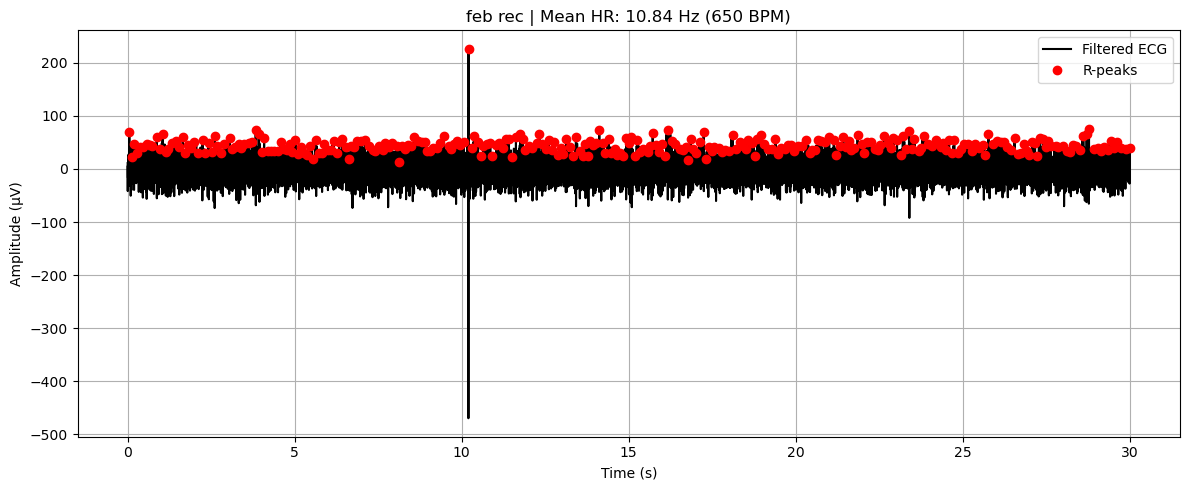

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp

# === PARAMETERS ===
elec_noise_freq = 60              # Powerline frequency
min_freq = 30                     # Bandpass lower bound (Hz)
max_freq = 200                    # Bandpass upper bound (Hz)
resample_rate = 1000             # Downsample to 1 kHz
ref_channel = 24                  # Reference electrode for bipolar
target_channel = 22              # Target ECG channel
duration_sec = 30                 # Duration of analysis (sec)
scaling_factor = 0.195            # ADC units to µV

# === DATA PATH ===
datapath = r"E:\heart_rate_recording\20250205_101517_ECG_freely_moving.rec\20250205_101517_ECG_freely_moving.rec"
# === LOAD & FILTER ===
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)
fs = resample_rate

# === GET TRACES & APPLY BIPOLAR REFERENCE ===
traces = recording.get_traces()
traces_bipolar = traces - traces[:, ref_channel, np.newaxis]
trace = traces_bipolar[:duration_sec * fs, target_channel] * scaling_factor  # in µV

# === PEAK DETECTION (R-waves) ===
min_rr_interval = 0.07  # Minimum RR interval in seconds (~850 BPM max)
peaks, _ = find_peaks(trace, distance=fs * min_rr_interval, height=np.percentile(trace, 75))

# === HEART RATE CALCULATION ===
rr_intervals = np.diff(peaks) / fs  # seconds
hr_hz = 1 / rr_intervals            # Hz
hr_bpm = 60 / rr_intervals          # BPM
mean_hr_hz = np.mean(hr_hz) if len(hr_hz) > 0 else np.nan
mean_hr_bpm = np.mean(hr_bpm) if len(hr_bpm) > 0 else np.nan

# === PLOT RESULTS ===
time = np.arange(len(trace)) / fs
plt.figure(figsize=(12, 5))
plt.plot(time, trace, label="Filtered ECG", color='black')
plt.plot(peaks / fs, trace[peaks], 'ro', label="R-peaks")
plt.title(f"feb rec | Mean HR: {mean_hr_hz:.2f} Hz ({mean_hr_bpm:.0f} BPM)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Bi-polar refrencing 

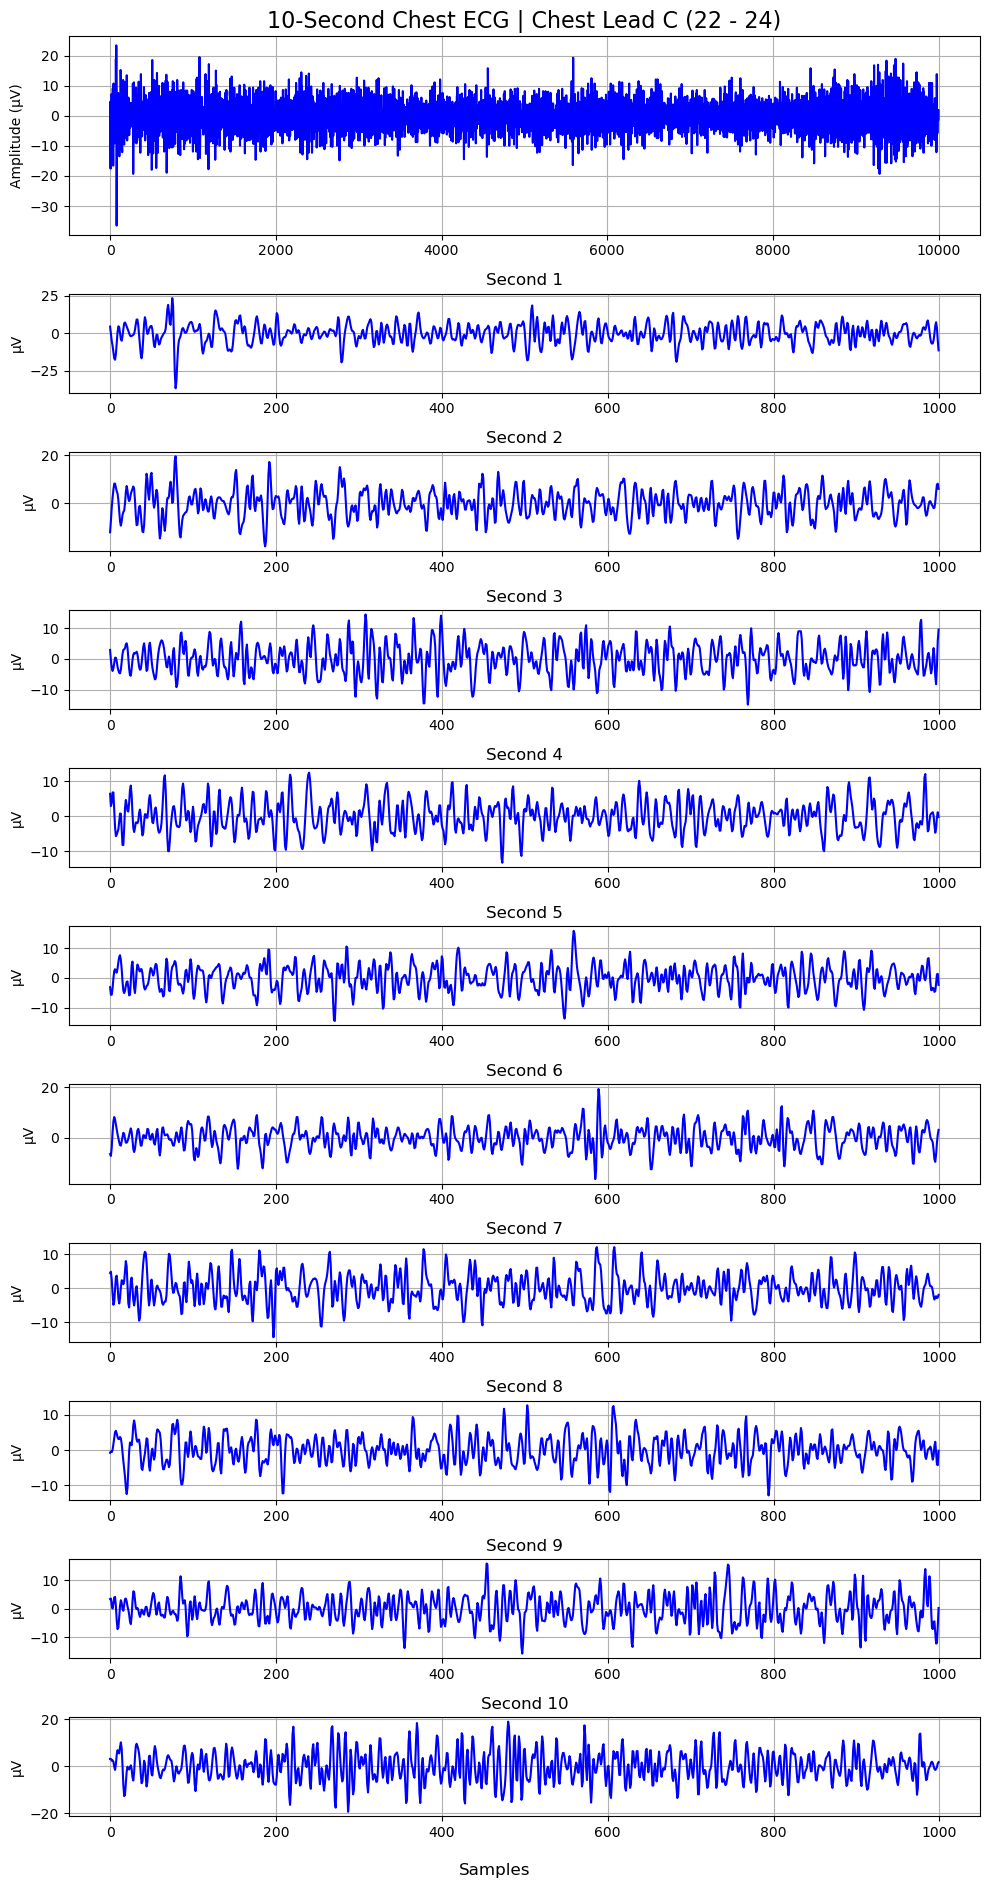

In [7]:
# === PARAMETERS ===
elec_noise_freq = 60
min_freq = 30
max_freq = 200
resample_rate = 1000
scaling_factor = 0.195  # µV per unit
datapath = r"E:\Aim1\AIM1\Day1_new\RI1_s3_5_p5_4_nRB3_20250621_105014.rec\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.rec"

# === LOAD & FILTER ===
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)

# === GET TRACES & MAP CHANNELS ===
traces = recording.get_traces()
channel_map = {ch: i for i, ch in enumerate(recording.get_channel_ids())}

# Ensure channels exist
ch10 = channel_map['10']
ch12 = channel_map['12']
ch22 = channel_map['22']
ch24 = channel_map['24']

# === BIPOLAR LEADS FOR CHEST ECG ===
lead_A = traces[:, ch10] - traces[:, ch12]  # Right upper - Left upper
lead_B = traces[:, ch22] - traces[:, ch24]  # Right lower - Left lower
lead_C = traces[:, ch10] - traces[:, ch24]  # RU - LL
lead_D = traces[:, ch22] - traces[:, ch12]  # RL - LU

# Choose lead to plot
selected_lead = lead_B          
lead_name = "Chest Lead C (22 - 24)"

# === CHUNKING ===
samples_per_second = resample_rate
samples_per_10sec = 10 * samples_per_second
samples_per_1sec = samples_per_second

start_idx = 0
end_idx = start_idx + samples_per_10sec
trace_10sec = selected_lead[start_idx:end_idx] * scaling_factor

# === PLOTTING ===
fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(11, 1, height_ratios=[2] + [1] * 10)

# Full 10-sec trace
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(trace_10sec, color='b')
ax1.set_title(f"10-Second Chest ECG | {lead_name}", fontsize=16)
ax1.set_ylabel("Amplitude (µV)")
ax1.grid()

# 1-second subplots
for i in range(10):
    chunk_start = i * samples_per_1sec
    chunk_end = chunk_start + samples_per_1sec
    ax = fig.add_subplot(gs[i + 1, 0])
    ax.plot(trace_10sec[chunk_start:chunk_end], color='b')
    ax.set_title(f"Second {i + 1}")
    ax.set_ylabel("µV")
    ax.grid()

fig.text(0.5, 0.04, "Samples", ha='center', fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

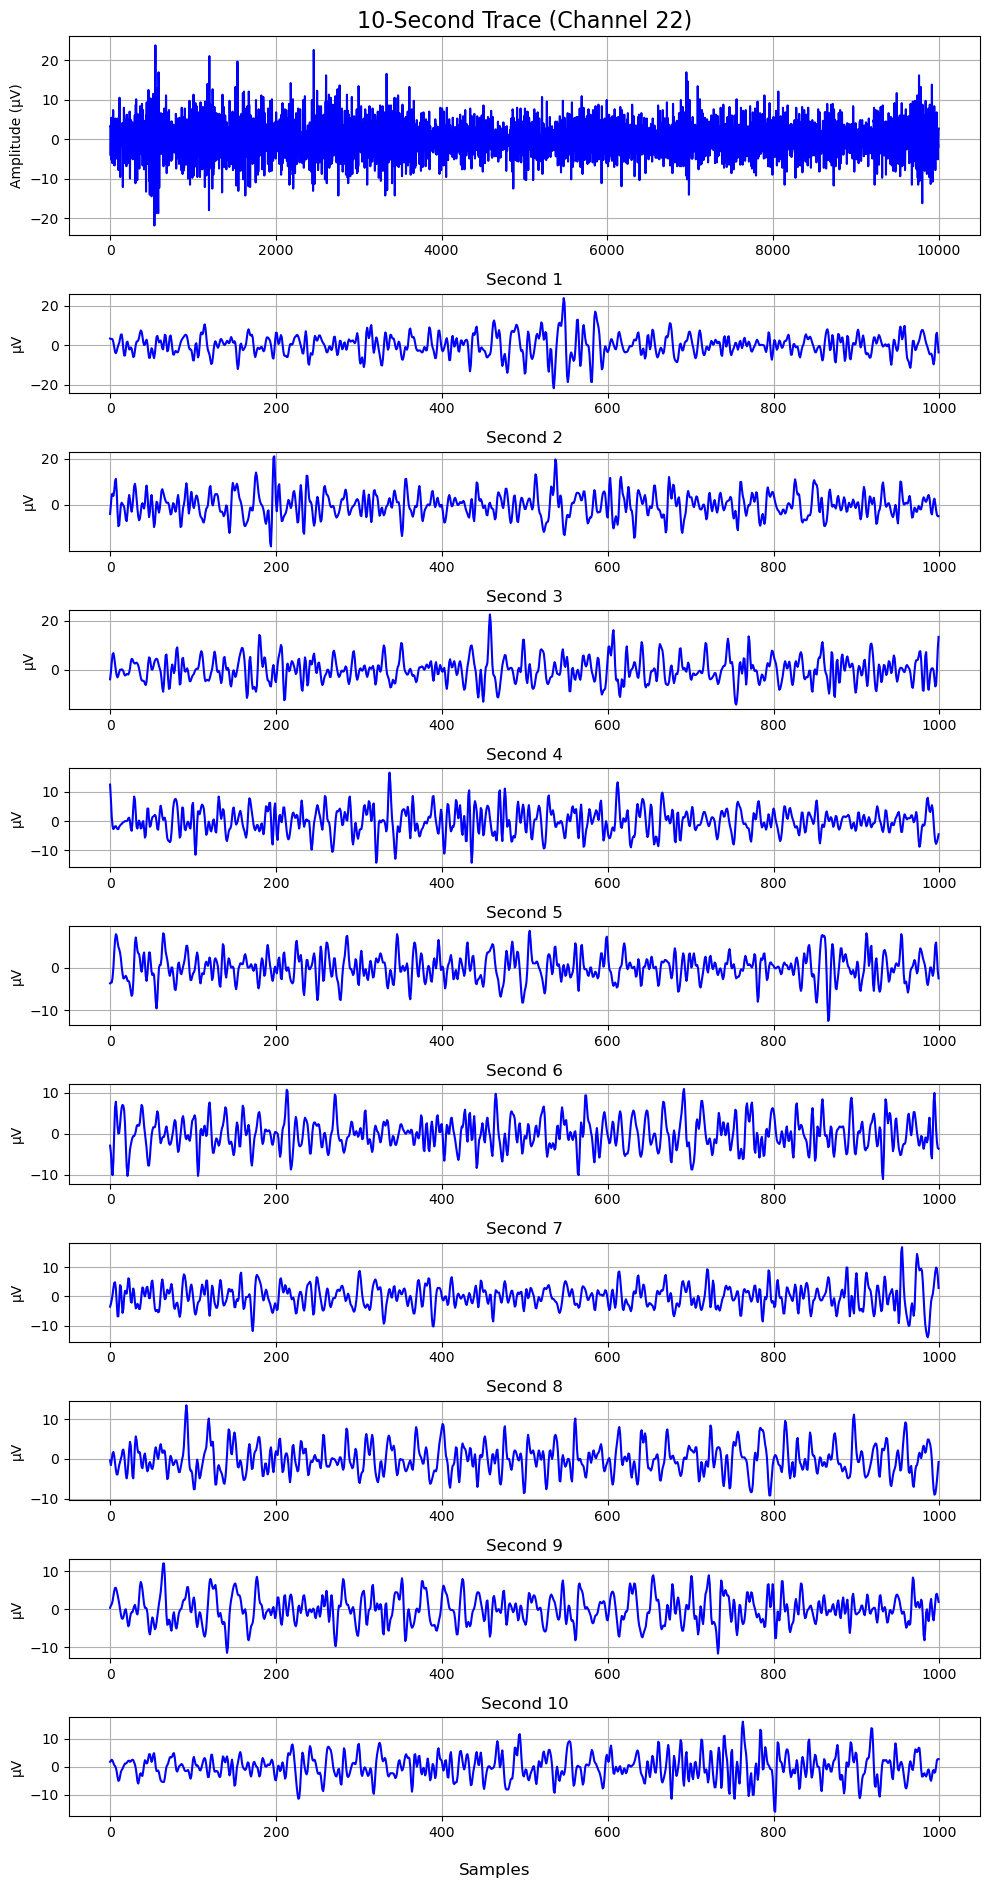

In [9]:
datapath = r"E:\Aim1\AIM1\Day1_new\RI1_s3_5_p5_4_nRB3_20250621_105014.rec\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.rec"

# === Parameters ===
channel = 22                 # Channel to visualize
ref_channel = 21            # Reference channel for bipolar (optional)
use_bipolar = False          # Set to True to use bipolar referencing

elec_noise_freq = 60         # Notch filter frequency
min_freq = 30                # Bandpass lower cutoff (Hz)
max_freq = 200              # Bandpass upper cutoff (Hz)
resample_rate = 1000         # New sampling rate
scaling_factor = 0.195       # Convert raw units to µV

duration_sec = 10            # Duration to plot (in seconds)
start_sec = 300                # Starting point in recording (in seconds)

# === Load and preprocess ===
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)

# === Get traces ===
traces = recording.get_traces()
fs = recording.get_sampling_frequency()

# Optional: Bipolar referencing
if use_bipolar:
    traces = traces - traces[:, ref_channel, np.newaxis]

# === Select time window ===
samples_per_sec = int(fs)
start_idx = int(start_sec * fs)
end_idx = int(start_idx + duration_sec * fs)
trace = traces[start_idx:end_idx, channel] * scaling_factor  # Convert to µV

# === Plotting ===
fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(11, 1, height_ratios=[2] + [1] * 10)

# Plot full 10-second trace
ax_main = fig.add_subplot(gs[0, 0])
ax_main.plot(trace, color='b')
ax_main.set_title(f"10-Second Trace (Channel {channel})", fontsize=16)
ax_main.set_ylabel("Amplitude (µV)")
ax_main.grid(True)

# Plot each 1-second chunk
for i in range(10):
    seg_start = i * samples_per_sec
    seg_end = seg_start + samples_per_sec
    chunk = trace[seg_start:seg_end]

    ax = fig.add_subplot(gs[i + 1, 0])
    ax.plot(chunk, color='b')
    ax.set_title(f"Second {i + 1}")
    ax.set_ylabel("µV")
    ax.grid(True)

# Add shared X label
fig.text(0.5, 0.04, "Samples", ha='center', fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

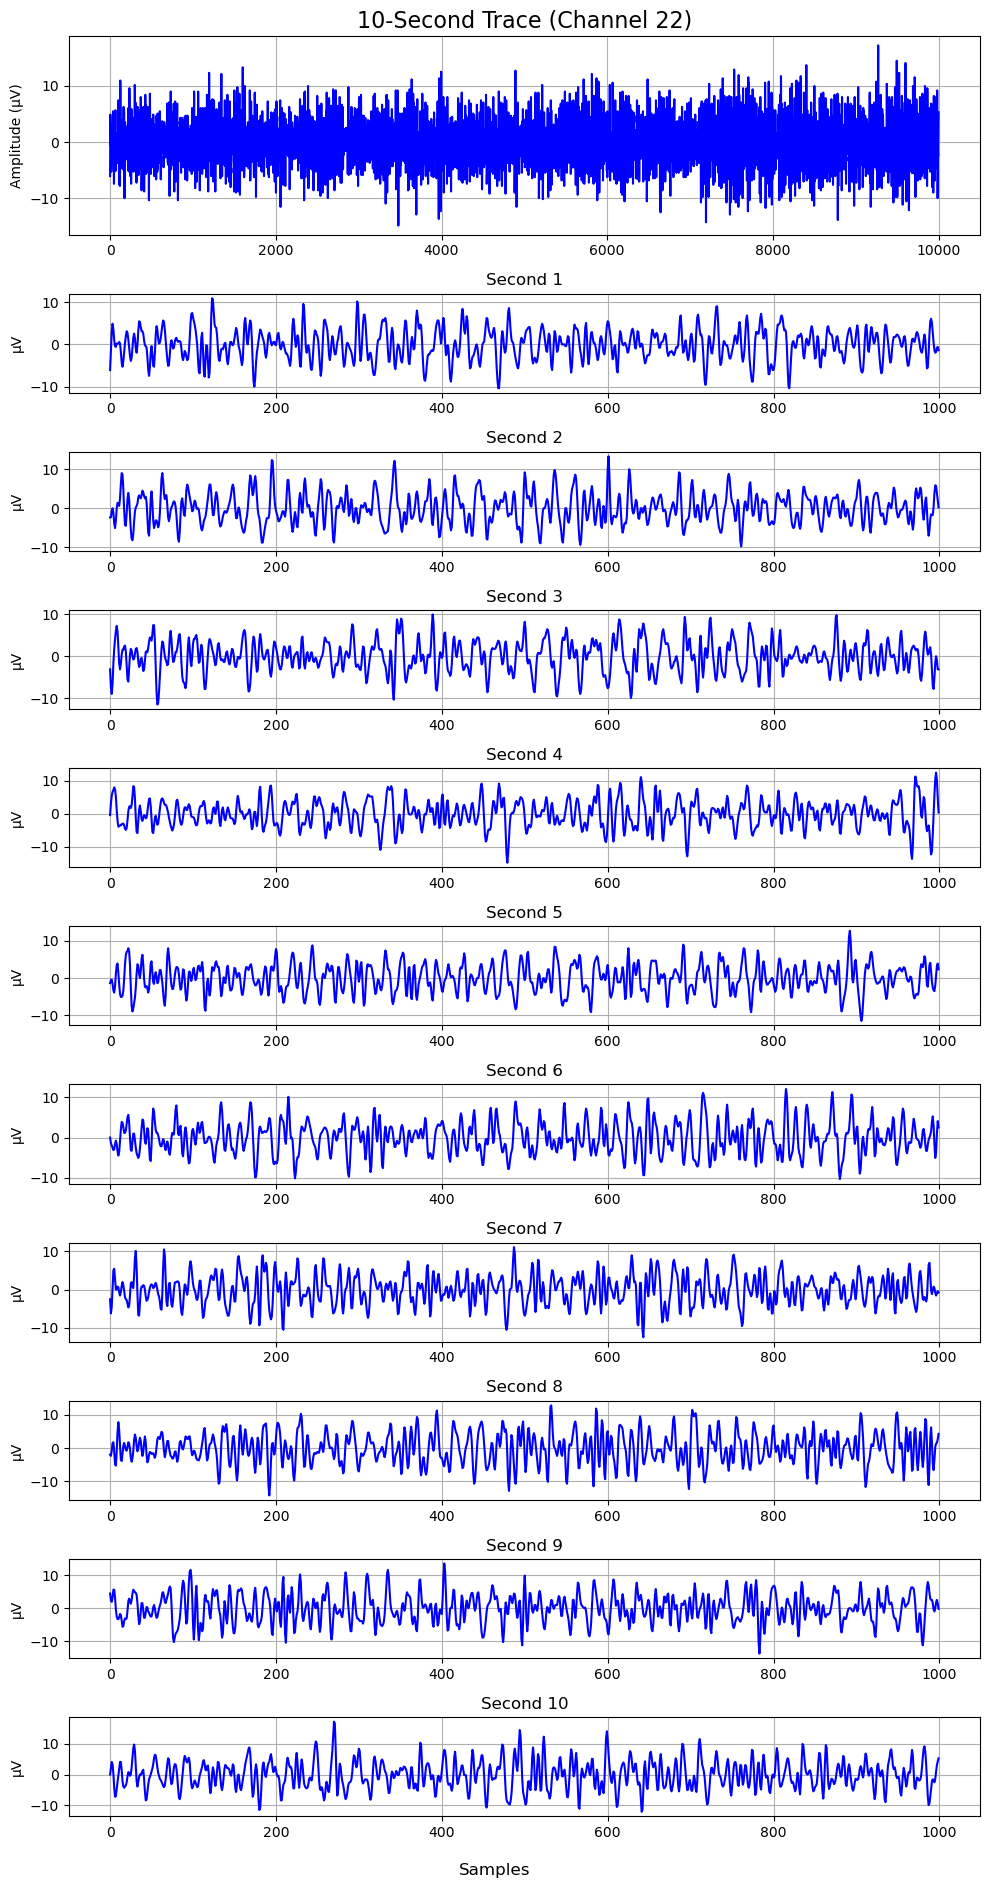

In [18]:
datapath = r"E:\Aim1\AIM1\Day1_new\RI1_s3_5_p5_4_nRB3_20250621_105014.rec\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.rec"

# === Parameters ===
channel = 22                 # Channel to visualize
ref_channel = 24            # Reference channel for bipolar (optional)
use_bipolar = True          # Set to True to use bipolar referencing

elec_noise_freq = 60         # Notch filter frequency
min_freq = 30                # Bandpass lower cutoff (Hz)
max_freq = 200              # Bandpass upper cutoff (Hz)
resample_rate = 1000         # New sampling rate
scaling_factor = 0.195       # Convert raw units to µV

duration_sec = 10            # Duration to plot (in seconds)
start_sec = 130                # Starting point in recording (in seconds)

# === Load and preprocess ===
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)

# === Get traces ===
traces = recording.get_traces()
fs = recording.get_sampling_frequency()

# Optional: Bipolar referencing
if use_bipolar:
    traces = traces - traces[:, ref_channel, np.newaxis]

# === Select time window ===
samples_per_sec = int(fs)
start_idx = int(start_sec * fs)
end_idx = int(start_idx + duration_sec * fs)
trace = traces[start_idx:end_idx, channel] * scaling_factor  # Convert to µV

# === Plotting ===
fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(11, 1, height_ratios=[2] + [1] * 10)

# Plot full 10-second trace
ax_main = fig.add_subplot(gs[0, 0])
ax_main.plot(trace, color='b')
ax_main.set_title(f"10-Second Trace (Channel {channel})", fontsize=16)
ax_main.set_ylabel("Amplitude (µV)")
ax_main.grid(True)

# Plot each 1-second chunk
for i in range(10):
    seg_start = i * samples_per_sec
    seg_end = seg_start + samples_per_sec
    chunk = trace[seg_start:seg_end]

    ax = fig.add_subplot(gs[i + 1, 0])
    ax.plot(chunk, color='b')
    ax.set_title(f"Second {i + 1}")
    ax.set_ylabel("µV")
    ax.grid(True)

# Add shared X label
fig.text(0.5, 0.04, "Samples", ha='center', fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

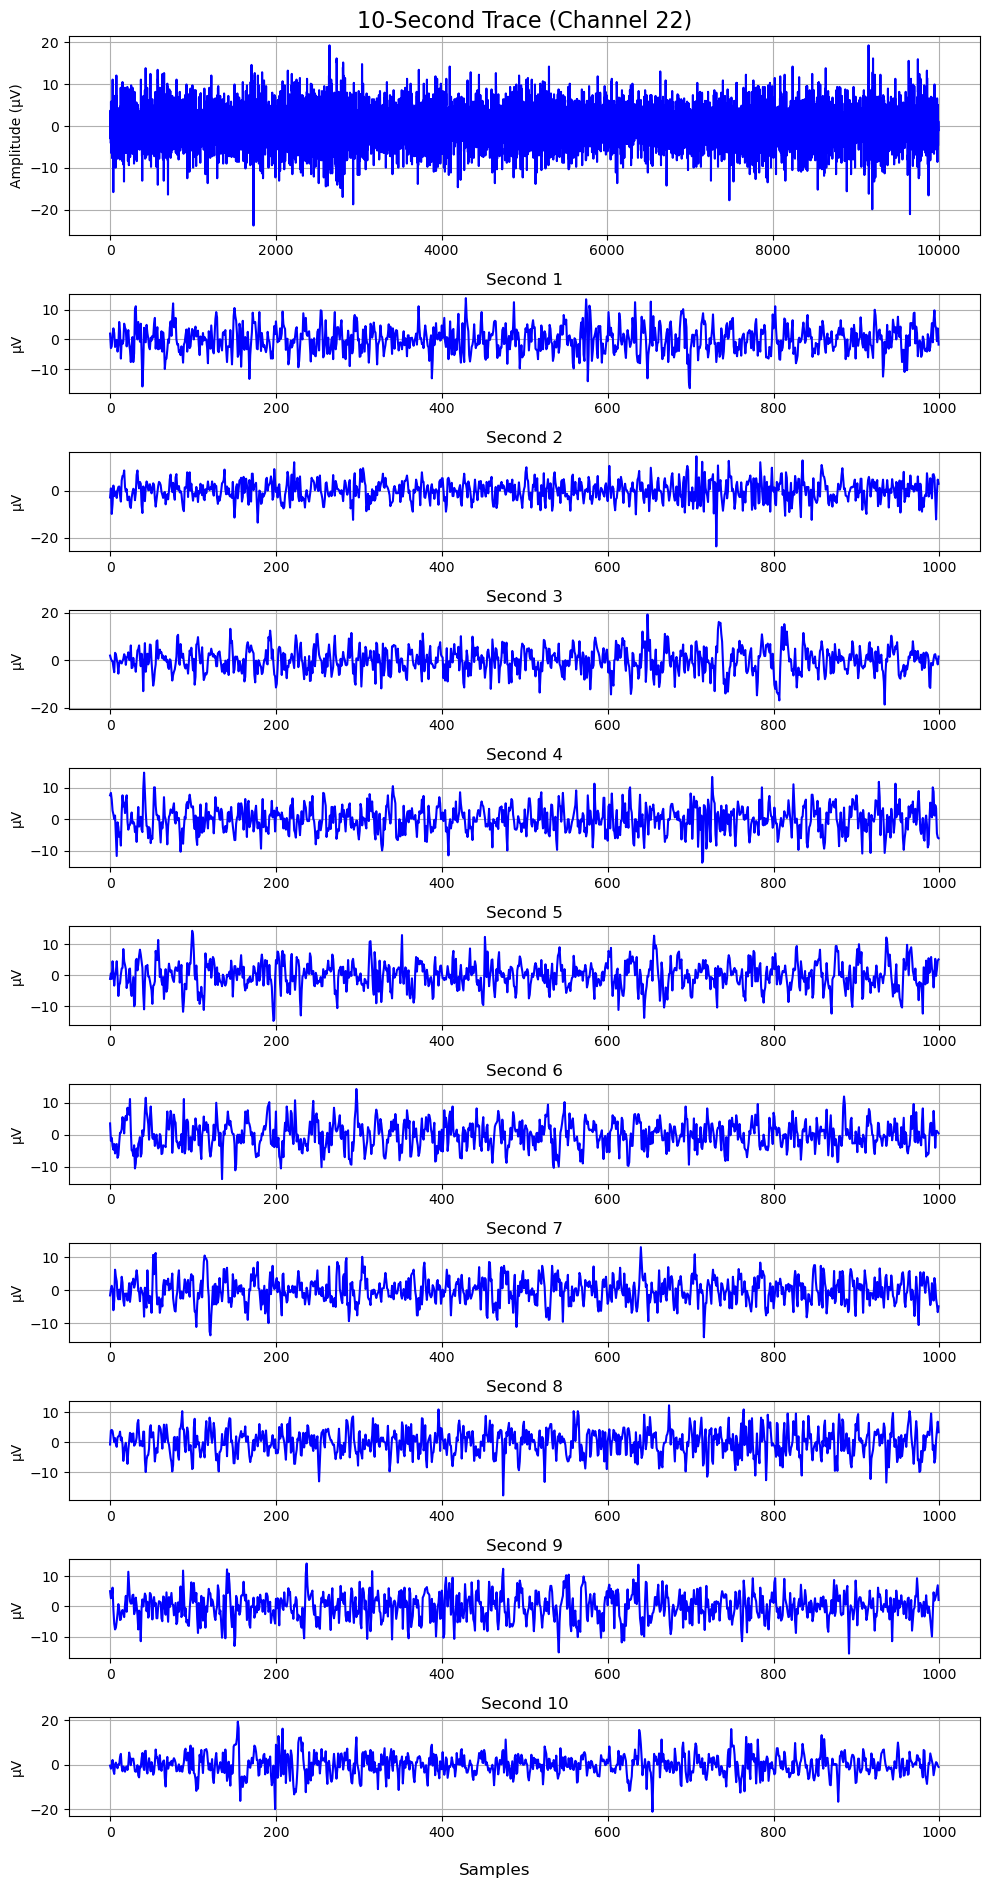

In [ ]:
# === Parameters ===
datapath = r"E:\Aim1\AIM1\Day1_new\RI1_s3_6_p5_3_nRB3_20250621_125312.rec\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.rec"
channel = 22                 # Channel to visualize
ref_channel = 21            # Reference channel for bipolar (optional)
use_bipolar = False          # Set to True to use bipolar referencing

elec_noise_freq = 60         # Notch filter frequency
min_freq = 30                # Bandpass lower cutoff (Hz)
max_freq = 1000              # Bandpass upper cutoff (Hz)
resample_rate = 1000         # New sampling rate
scaling_factor = 0.195       # Convert raw units to µV

duration_sec = 10            # Duration to plot (in seconds)
start_sec = 130                # Starting point in recording (in seconds)

# === Load and preprocess ===
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)

# === Get traces ===
traces = recording.get_traces()
fs = recording.get_sampling_frequency()

# Optional: Bipolar referencing
if use_bipolar:
    traces = traces - traces[:, ref_channel, np.newaxis]

# === Select time window ===
samples_per_sec = int(fs)
start_idx = int(start_sec * fs)
end_idx = int(start_idx + duration_sec * fs)
trace = traces[start_idx:end_idx, channel] * scaling_factor  # Convert to µV

# === Plotting ===
fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(11, 1, height_ratios=[2] + [1] * 10)

# Plot full 10-second trace
ax_main = fig.add_subplot(gs[0, 0])
ax_main.plot(trace, color='b')
ax_main.set_title(f"10-Second Trace (Channel {channel})", fontsize=16)
ax_main.set_ylabel("Amplitude (µV)")
ax_main.grid(True)

# Plot each 1-second chunk
for i in range(10):
    seg_start = i * samples_per_sec
    seg_end = seg_start + samples_per_sec
    chunk = trace[seg_start:seg_end]

    ax = fig.add_subplot(gs[i + 1, 0])
    ax.plot(chunk, color='b')
    ax.set_title(f"Second {i + 1}")
    ax.set_ylabel("µV")
    ax.grid(True)

# Add shared X label
fig.text(0.5, 0.04, "Samples", ha='center', fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

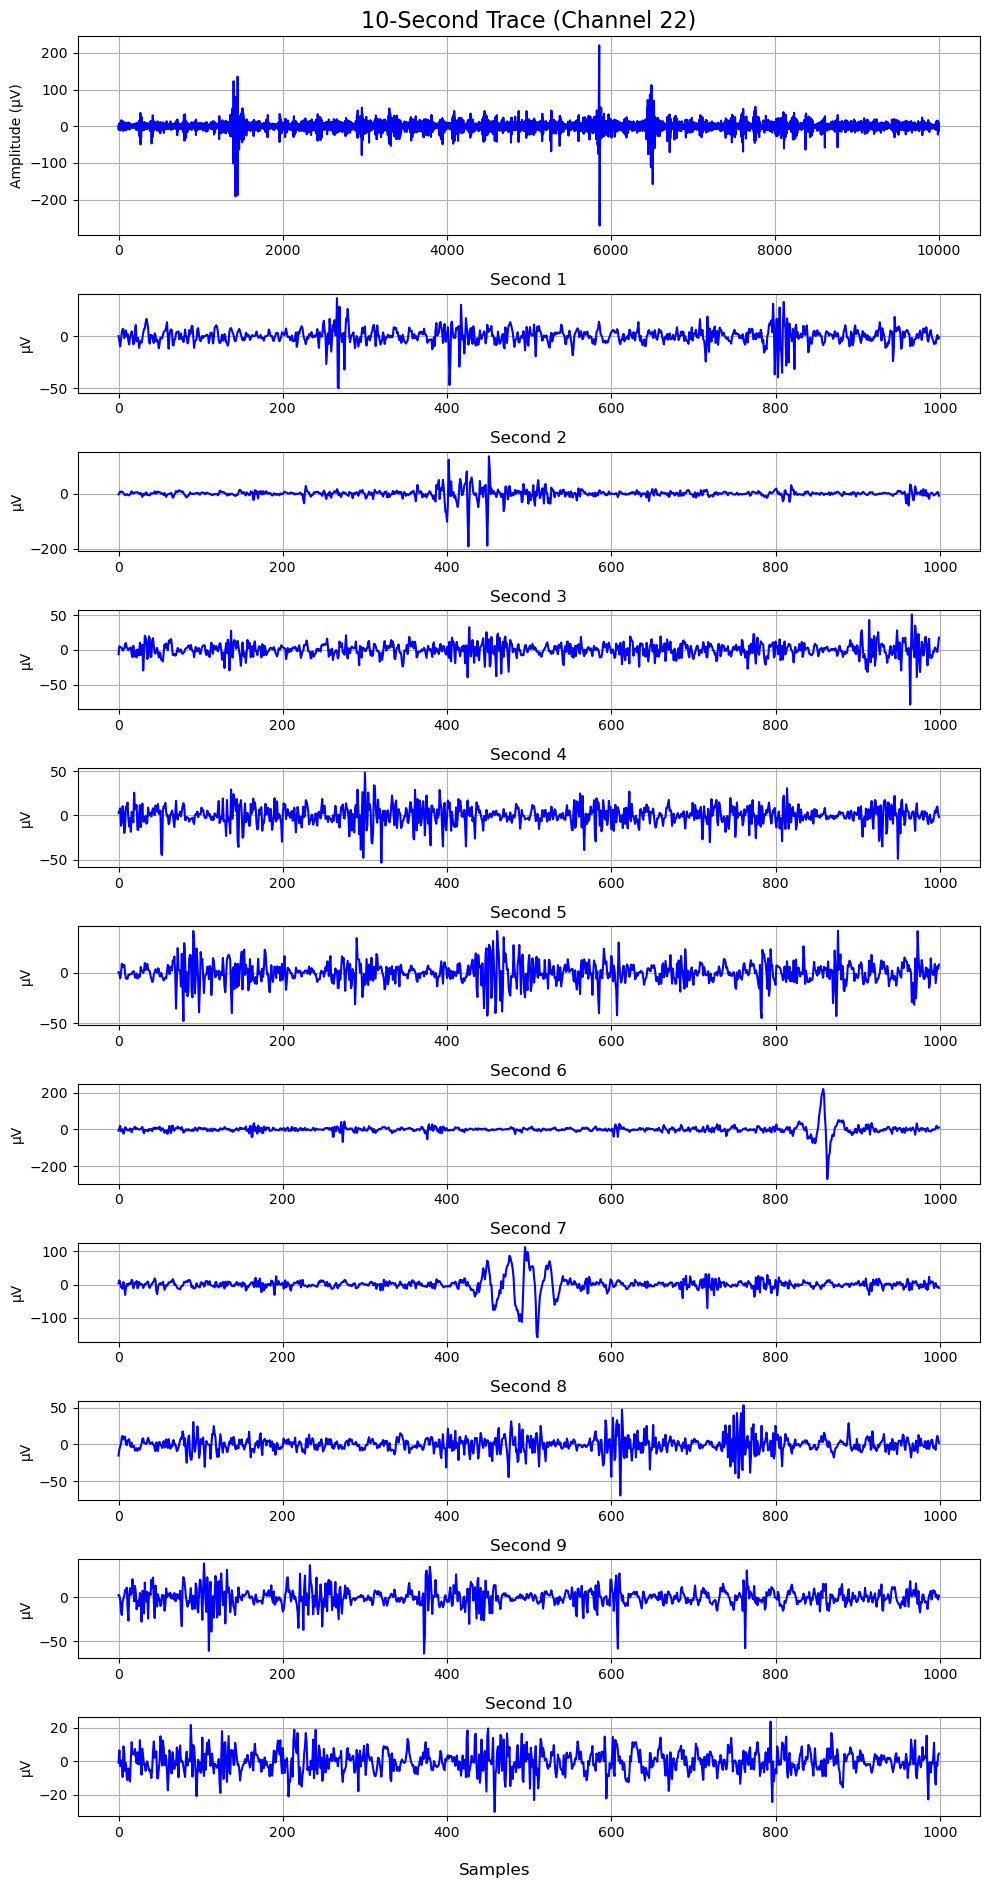

In [19]:
# === Parameters ===
datapath = "E:\Aim1\AIM1\Day1_new\RI1_s4_7_p5_2_nRB3_20250621_150707.rec\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.rec"
channel = 22                 # Channel to visualize
ref_channel = 21            # Reference channel for bipolar (optional)
use_bipolar = False          # Set to True to use bipolar referencing

elec_noise_freq = 60         # Notch filter frequency
min_freq = 30                # Bandpass lower cutoff (Hz)
max_freq = 1000              # Bandpass upper cutoff (Hz)
resample_rate = 1000         # New sampling rate
scaling_factor = 0.195       # Convert raw units to µV

duration_sec = 10            # Duration to plot (in seconds)
start_sec = 130                # Starting point in recording (in seconds)

# === Load and preprocess ===
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)

# === Get traces ===
traces = recording.get_traces()
fs = recording.get_sampling_frequency()

# Optional: Bipolar referencing
if use_bipolar:
    traces = traces - traces[:, ref_channel, np.newaxis]

# === Select time window ===
samples_per_sec = int(fs)
start_idx = int(start_sec * fs)
end_idx = int(start_idx + duration_sec * fs)
trace = traces[start_idx:end_idx, channel] * scaling_factor  # Convert to µV

# === Plotting ===
fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(11, 1, height_ratios=[2] + [1] * 10)

# Plot full 10-second trace
ax_main = fig.add_subplot(gs[0, 0])
ax_main.plot(trace, color='b')
ax_main.set_title(f"10-Second Trace (Channel {channel})", fontsize=16)
ax_main.set_ylabel("Amplitude (µV)")
ax_main.grid(True)

# Plot each 1-second chunk
for i in range(10):
    seg_start = i * samples_per_sec
    seg_end = seg_start + samples_per_sec
    chunk = trace[seg_start:seg_end]

    ax = fig.add_subplot(gs[i + 1, 0])
    ax.plot(chunk, color='b')
    ax.set_title(f"Second {i + 1}")
    ax.set_ylabel("µV")
    ax.grid(True)

# Add shared X label
fig.text(0.5, 0.04, "Samples", ha='center', fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

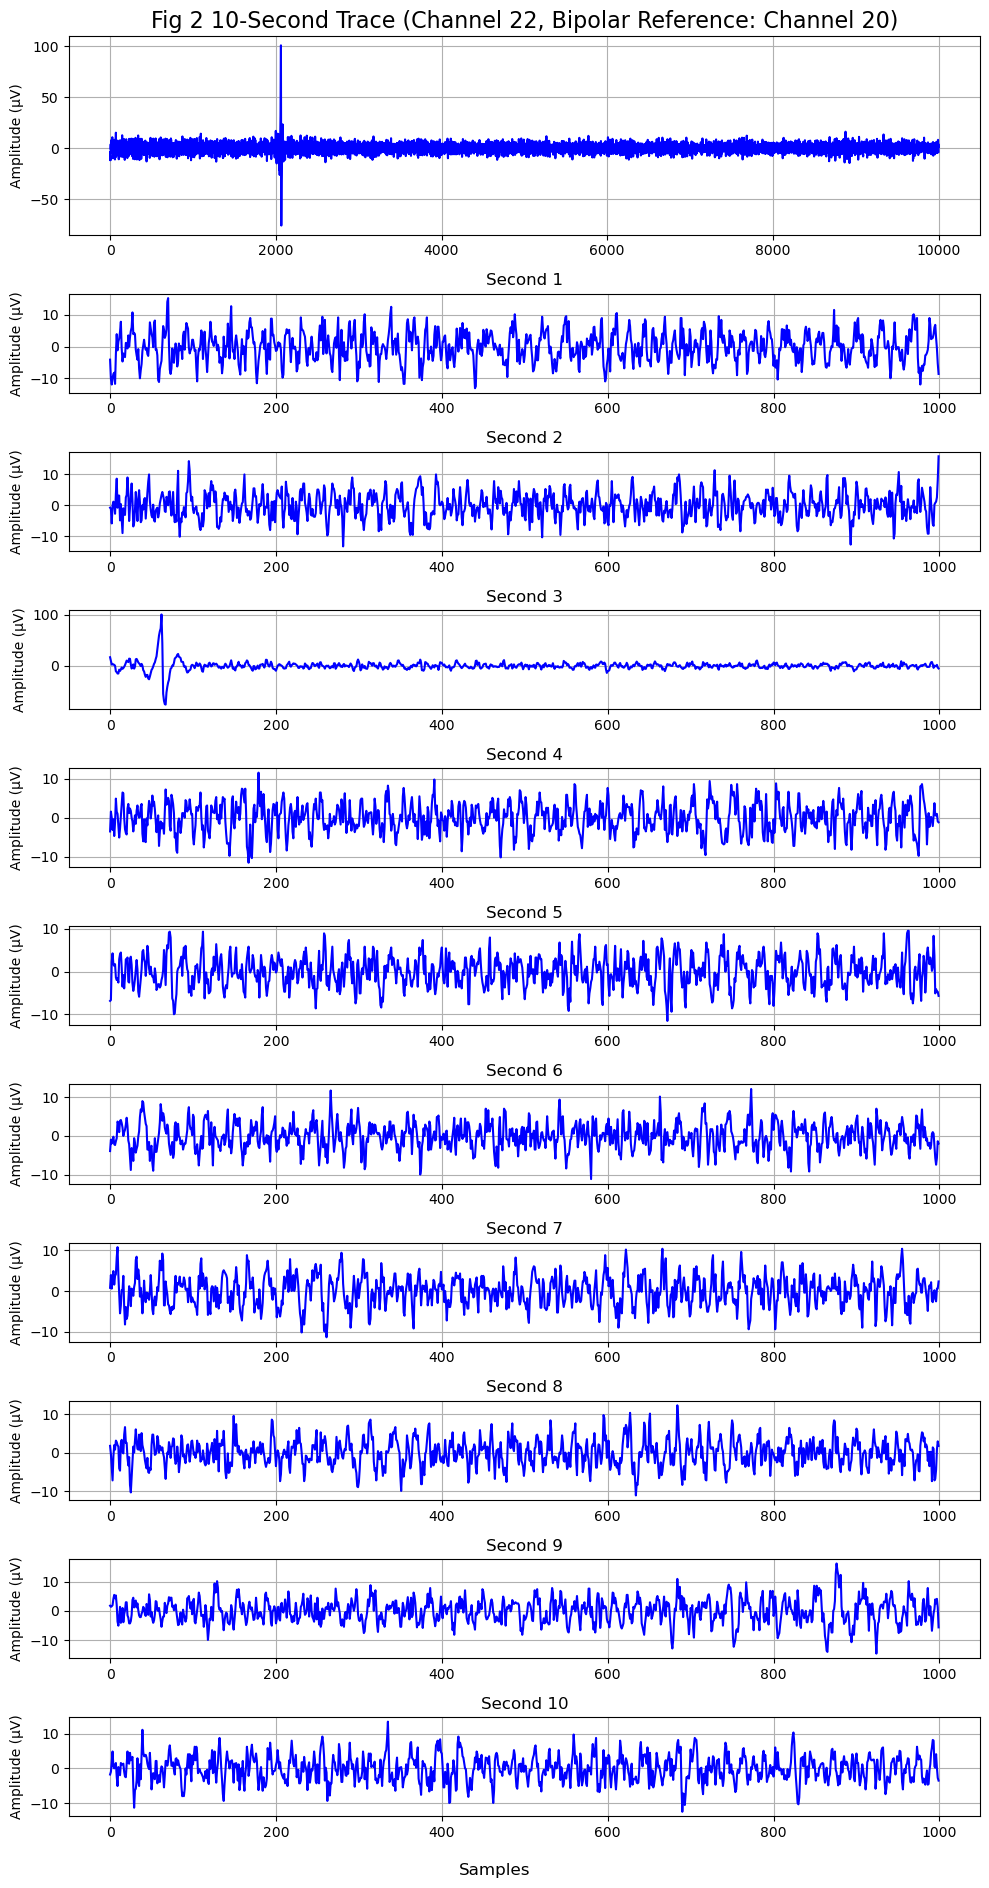

In [12]:
# Parameters
elec_noise_freq = 60
min_freq = 30
max_freq = 1000
resample_rate = 1000
datapath = r"E:\Aim1\AIM1\Day1_new\RI1_s4_8_p5_1_nRB3_20250621_165214.rec\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.rec"
# Load and preprocess the recording
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)
traces = recording.get_traces()

# Subtract Bipolar Reference
ref_channel = 20  # Define the reference channel
traces_bipolar = traces - traces[:, ref_channel, np.newaxis]  # Subtract reference channel from all others

# Define chunking parameters
samples_per_second = resample_rate
samples_per_10sec = 10 * samples_per_second
samples_per_1sec = samples_per_second

# Select the start of the chunk (e.g., first 10 seconds of recording)
start_idx = 0
end_idx = start_idx + samples_per_10sec

# Extract the 10-second trace for a specific channel (e.g., channel 26)
channel = 22
ten_sec_trace = traces_bipolar[start_idx:end_idx, channel]

# Convert data to microvolts if necessary
scaling_factor = 0.195  # Example: conversion from ADC units to µV
ten_sec_trace = ten_sec_trace * scaling_factor

# Create a figure with one large plot for the 10-second trace and subplots for 1-second chunks
fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(11, 1, height_ratios=[2] + [1] * 10)  # 1 large plot + 10 smaller plots

# Plot the full 10-second trace at the top
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ten_sec_trace, color='b')
ax1.set_title(f"Fig 2 10-Second Trace (Channel {channel}, Bipolar Reference: Channel {ref_channel})", fontsize=16)
ax1.set_ylabel("Amplitude (µV)")
ax1.grid()

# Plot the 1-second subplots
for i in range(10):
    chunk_start = i * samples_per_1sec
    chunk_end = chunk_start + samples_per_1sec
    ax = fig.add_subplot(gs[i + 1, 0])
    ax.plot(ten_sec_trace[chunk_start:chunk_end], color='b')
    ax.set_title(f"Second {i + 1}")
    ax.set_ylabel("Amplitude (µV)")
    ax.grid()

# Add a common x-axis label
fig.text(0.5, 0.04, "Samples", ha='center', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()


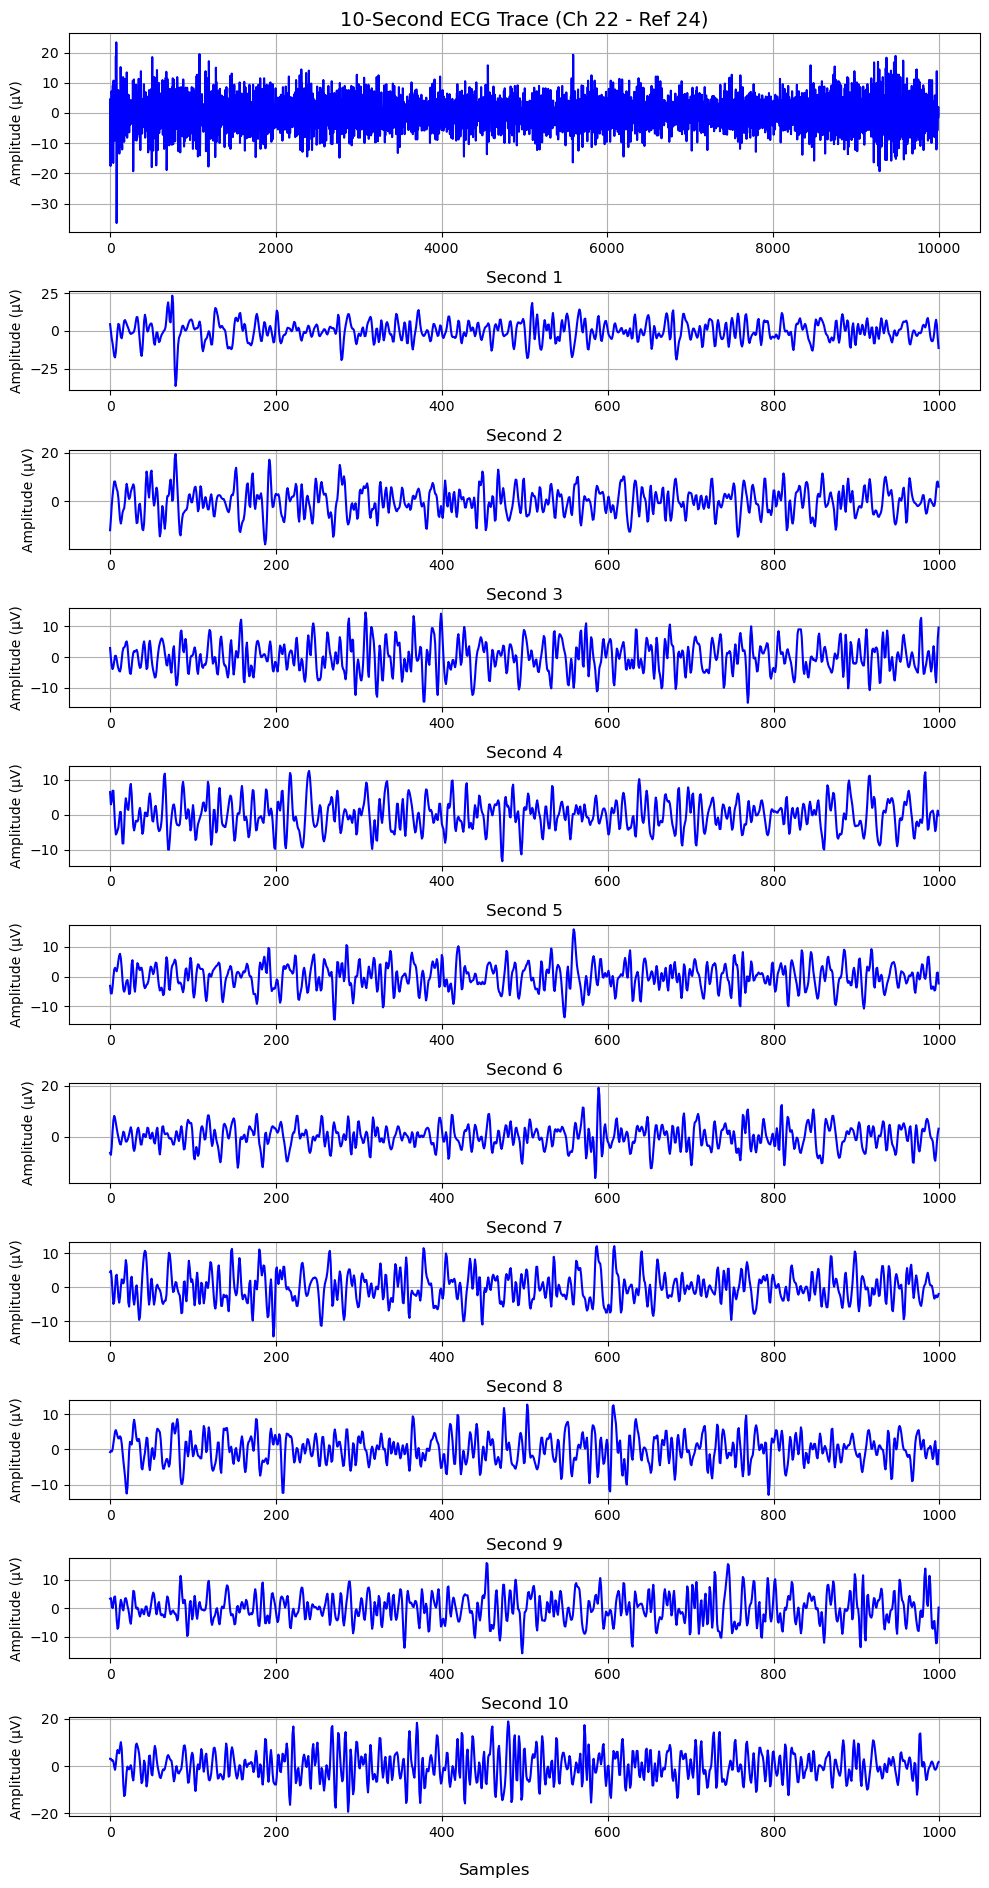

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
from scipy.signal import butter, filtfilt, decimate

# === Parameters ===
elec_noise_freq = 60           # Notch filter frequency
bandpass_low = 30               # Bandpass low cutoff (Hz)
bandpass_high = 200            # Bandpass high cutoff (Hz)
resample_rate = 1000           # Final sampling rate for analysis/plotting
scaling_factor = 0.195         # µV per bit (adjust if needed)

# === File and Channels ===
datapath = r"E:\Aim1\AIM1\Day1_new\RI1_s3_5_p5_4_nRB3_20250621_105014.rec\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.rec"
recording = se.read_spikegadgets(datapath, stream_id='trodes')

# === Preprocessing ===
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=bandpass_low, freq_max=bandpass_high)
recording = sp.resample(recording, resample_rate=resample_rate)
fs = recording.get_sampling_frequency()

# === Get Traces and Bipolar Reference ===
traces = recording.get_traces()
ref_channel = 24              # Reference channel (adjust if needed)
channel = 22                  # Target ECG channel (adjust if needed)
traces_bipolar = traces - traces[:, ref_channel][:, np.newaxis]

# === Extract 10-Second Segment ===
samples_per_sec = int(fs)
samples_per_10sec = 10 * samples_per_sec
start_idx = 0
end_idx = start_idx + samples_per_10sec
trace_10sec = traces_bipolar[start_idx:end_idx, channel] * scaling_factor

# === Plot ===
fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(11, 1, height_ratios=[2] + [1] * 10)

# Plot full 10-second trace
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(trace_10sec, color='b')
ax1.set_title(f"10-Second ECG Trace (Ch {channel} - Ref {ref_channel})", fontsize=14)
ax1.set_ylabel("Amplitude (µV)")
ax1.grid()

# Plot each 1-second chunk
for i in range(10):
    chunk_start = i * samples_per_sec
    chunk_end = chunk_start + samples_per_sec
    ax = fig.add_subplot(gs[i + 1, 0])
    ax.plot(trace_10sec[chunk_start:chunk_end], color='b')
    ax.set_title(f"Second {i + 1}")
    ax.set_ylabel("Amplitude (µV)")
    ax.grid()

# Add x-axis label
fig.text(0.5, 0.04, "Samples", ha='center', fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp

# === PARAMETERS ===
elec_noise_freq = 60              # Powerline frequency
min_freq = 30                     # Bandpass lower bound (Hz)
max_freq = 200                    # Bandpass upper bound (Hz)
resample_rate = 1000             # Downsample to 1 kHz
ref_channel = 24                  # Reference electrode for bipolar
target_channel = 22              # Target ECG channel
duration_sec = 30                 # Duration of analysis (sec)
scaling_factor = 0.195            # ADC units to µV

# === DATA PATH ===
datapath = r"E:\Aim1\AIM1\Day1_new\RI1_s3_5_p5_4_nRB3_20250621_105014.rec\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.rec"

# === LOAD & FILTER ===
recording = se.read_spikegadgets(datapath, stream_id='trodes')
recording = sp.notch_filter(recording, freq=elec_noise_freq)
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
recording = sp.resample(recording, resample_rate=resample_rate)
fs = resample_rate

# === GET TRACES & APPLY BIPOLAR REFERENCE ===
traces = recording.get_traces()
traces_bipolar = traces - traces[:, ref_channel, np.newaxis]
trace = traces_bipolar[:duration_sec * fs, target_channel] * scaling_factor  # in µV

# === PEAK DETECTION (R-waves) ===
min_rr_interval = 0.07  # Minimum RR interval in seconds (~850 BPM max)
peaks, _ = find_peaks(trace, distance=fs * min_rr_interval, height=np.percentile(trace, 75))

# === HEART RATE CALCULATION ===
rr_intervals = np.diff(peaks) / fs  # seconds
hr_hz = 1 / rr_intervals            # Hz
hr_bpm = 60 / rr_intervals          # BPM
mean_hr_hz = np.mean(hr_hz) if len(hr_hz) > 0 else np.nan
mean_hr_bpm = np.mean(hr_bpm) if len(hr_bpm) > 0 else np.nan

# === PLOT RESULTS ===
time = np.arange(len(trace)) / fs
plt.figure(figsize=(12, 5))
plt.plot(time, trace, label="Filtered ECG", color='black')
plt.plot(peaks / fs, trace[peaks], 'ro', label="R-peaks")
plt.title(f"RI1_s3_5_p5_4_nRB3 | Mean HR: {mean_hr_hz:.2f} Hz ({mean_hr_bpm:.0f} BPM)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



Processing: RI1_s3_5_p5_4_nRB3_20250621_105014_merged.rec


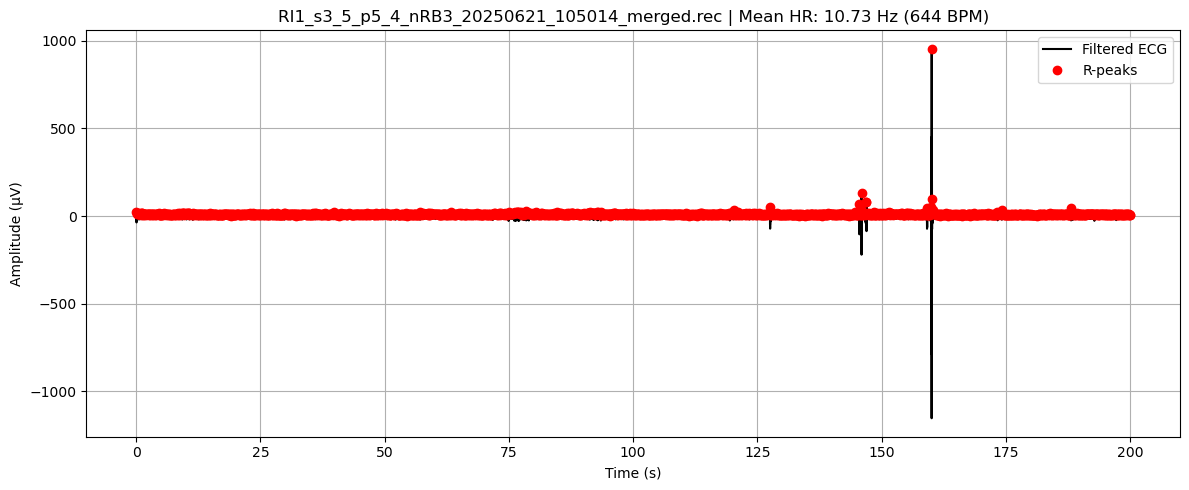


Processing: RI2_s3_5_p5_4_nRB3_20250621_112618_merged.rec


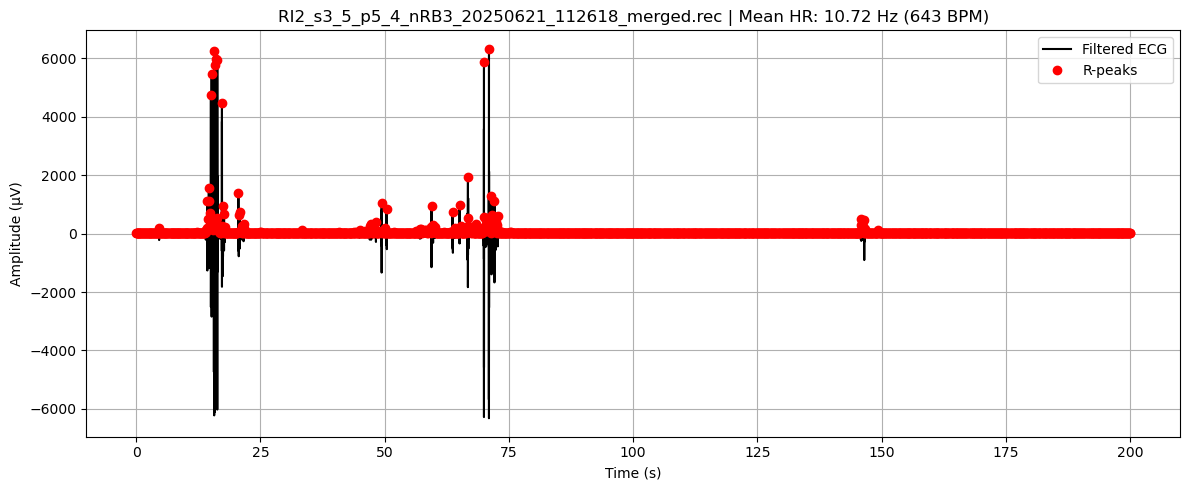


Processing: RI1_s4_7_p5_2_nRB3_20250621_150707_merged.rec


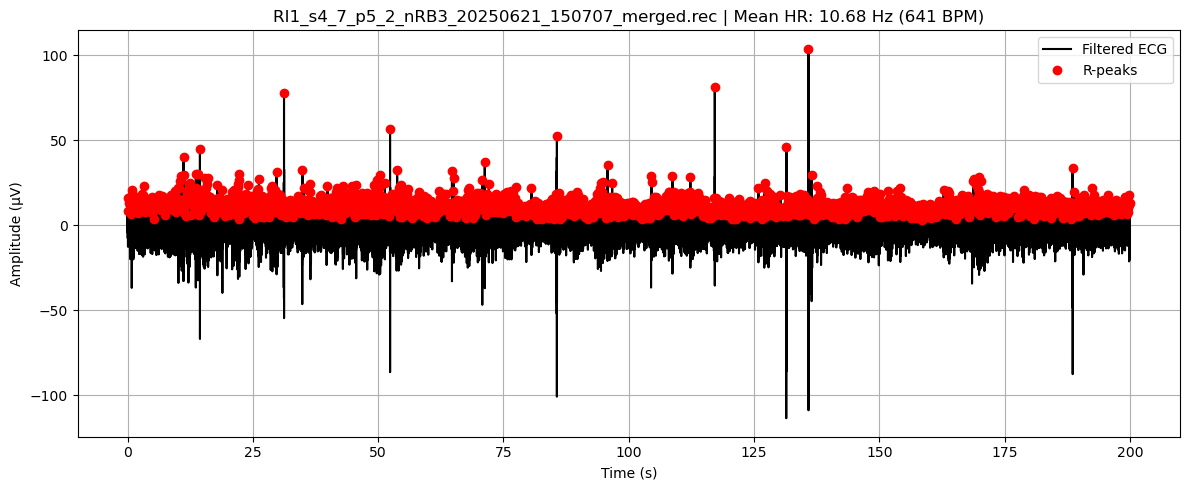


Processing: RI2_s4_7_p5_2_nRB3_20250621_152519_merged.rec


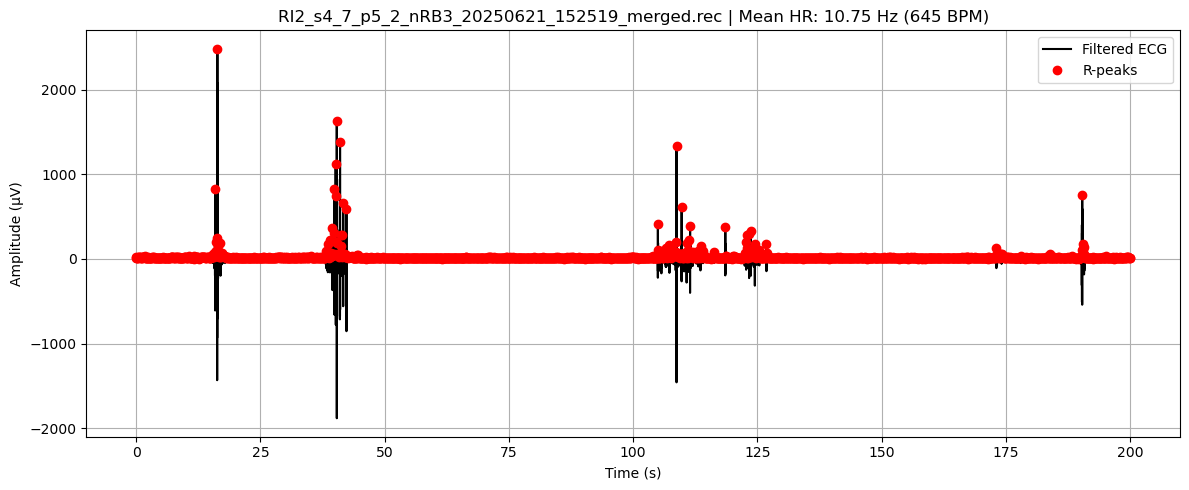


--- Summary ---
RI1_s3_5_p5_4_nRB3_20250621_105014_merged.rec: HR = 643.8 BPM (10.73 Hz), beats detected: 2053
RI2_s3_5_p5_4_nRB3_20250621_112618_merged.rec: HR = 643.3 BPM (10.72 Hz), beats detected: 2049
RI1_s4_7_p5_2_nRB3_20250621_150707_merged.rec: HR = 641.0 BPM (10.68 Hz), beats detected: 2041
RI2_s4_7_p5_2_nRB3_20250621_152519_merged.rec: HR = 645.2 BPM (10.75 Hz), beats detected: 2055


In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp

# === PARAMETERS ===
elec_noise_freq = 60
min_freq = 30
max_freq = 200
resample_rate = 1000
ref_channel = 24
target_channel = 22
duration_sec = 200
scaling_factor = 0.195
min_rr_interval = 0.07  # 70 ms = ~850 BPM max

# === LIST OF FILES ===
rec_files = [
    r"E:\Aim1\AIM1\Day1_new\RI1_s3_5_p5_4_nRB3_20250621_105014.rec\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.rec",
    r"E:\Aim1\AIM1\Day1_new\RI2_s3_5_p5_4_nRB3_20250621_112618.rec\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.rec",  # Add remaining 8 full paths here
    r"E:\Aim1\AIM1\Day1_new\RI1_s4_7_p5_2_nRB3_20250621_150707.rec\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.rec",
    r"E:\Aim1\AIM1\Day1_new\RI2_s4_7_p5_2_nRB3_20250621_152519.rec\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.rec",
]

# === OUTPUTS STORAGE ===
results = []

for datapath in rec_files:
    try:
        print(f"\nProcessing: {os.path.basename(datapath)}")
        
        # --- Load and preprocess ---
        recording = se.read_spikegadgets(datapath, stream_id='trodes')
        recording = sp.notch_filter(recording, freq=elec_noise_freq)
        recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
        recording = sp.resample(recording, resample_rate=resample_rate)
        fs = resample_rate

        # --- Get traces & bipolar reference ---
        traces = recording.get_traces()
        traces_bipolar = traces - traces[:, ref_channel, np.newaxis]
        trace = traces_bipolar[:duration_sec * fs, target_channel] * scaling_factor

        # --- Peak detection ---
        peaks, _ = find_peaks(trace, distance=fs * min_rr_interval, height=np.percentile(trace, 75))
        rr_intervals = np.diff(peaks) / fs
        hr_hz = 1 / rr_intervals
        hr_bpm = 60 / rr_intervals
        mean_hr_hz = np.mean(hr_hz) if len(hr_hz) > 0 else np.nan
        mean_hr_bpm = np.mean(hr_bpm) if len(hr_bpm) > 0 else np.nan

        # --- Save result ---
        results.append({
            "file": os.path.basename(datapath),
            "mean_HR_Hz": mean_hr_hz,
            "mean_HR_BPM": mean_hr_bpm,
            "n_beats": len(peaks)
        })

        # --- Plot ---
        time = np.arange(len(trace)) / fs
        plt.figure(figsize=(12, 5))
        plt.plot(time, trace, label="Filtered ECG", color='black')
        plt.plot(peaks / fs, trace[peaks], 'ro', label="R-peaks")
        plt.title(f"{os.path.basename(datapath)} | Mean HR: {mean_hr_hz:.2f} Hz ({mean_hr_bpm:.0f} BPM)")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude (µV)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error processing {datapath}: {e}")
        results.append({
            "file": os.path.basename(datapath),
            "error": str(e)
        })

# === OPTIONAL: PRINT SUMMARY ===
print("\n--- Summary ---")
for r in results:
    if "error" in r:
        print(f"{r['file']}: ERROR - {r['error']}")
    else:
        print(f"{r['file']}: HR = {r['mean_HR_BPM']:.1f} BPM ({r['mean_HR_Hz']:.2f} Hz), beats detected: {r['n_beats']}")



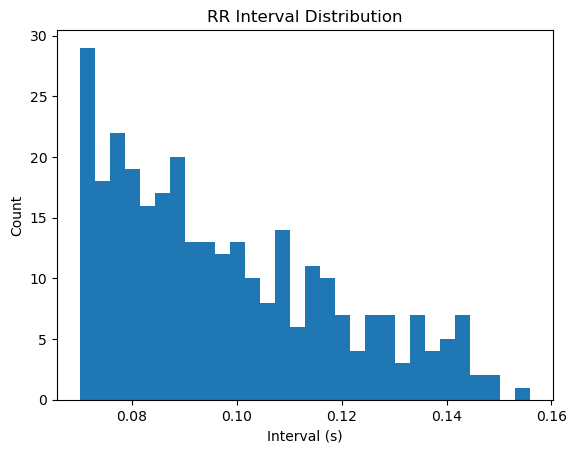

In [11]:
plt.hist(rr_intervals, bins=30)
plt.title("RR Interval Distribution")
plt.xlabel("Interval (s)")
plt.ylabel("Count")
plt.show()
